43.635972674210706
43.635972674210706
43.635972674210706
43.635972674210706
43.635972674210706


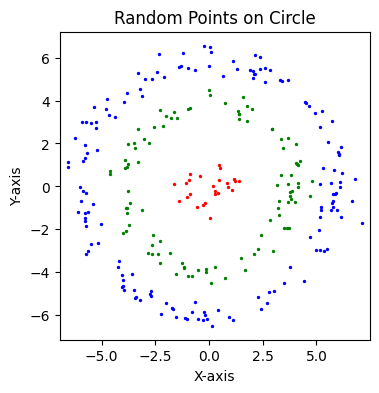

In [17]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
#generate some random data
def generate_points_on_circle(radius, num_points,noise):
    xpoints=[]
    ypoints=[]
    np.random.seed(37)
    for _ in range(num_points):
        # Generate a random angle in radians
       
        theta =np.random.uniform(0, 2 * math.pi)
        
        # Calculate x and y coordinates using polar coordinates
   
        x =  (radius+np.random.normal(0,noise,1)) * math.cos(theta)
      
        y =  (radius+np.random.normal(0,noise,1)) * math.sin(theta)
        
        xpoints.append(x)
        ypoints.append(y)
    
    return np.array(xpoints), np.array(ypoints)
#Parameteers
categories=3
factor=25
radius=[1,4,6]
noise=.4
#Contruct X(:,0) annd X(:,1)
Xp=np.empty((0,1))
Yp=np.empty((0,1))

for c in range(categories):
    num_points=factor*radius[c]
    xpoints,ypoints = generate_points_on_circle(radius[c], int(num_points),noise)
    Xp=np.vstack((Xp,xpoints))
    Yp=np.vstack((Yp,ypoints))
    #Scatter plot each color category
    #plt.scatter(xpoints,ypoints,s=2,color=color[c]) 
# plt.axis('equal')  # To maintain aspect ratio 
# plt.title('Random Points on Circle') 
# plt.xlabel('X-axis') 
# plt.ylabel('Y-axis')

#Construct X Matrix from data
X=np.hstack((Xp,Yp))
n_samples = X.shape[0]
One_matrix=np.ones((n_samples,n_samples))
Id_matrix=np.identity((n_samples))
#Variety of Kernels for PCA
def polynomial_kernel(X, Y, degree=1, c=0):
    return (np.dot(X, Y) + c) ** degree
def rbf_kernel(X, Y, gamma=.5):
    return np.exp(-gamma * np.linalg.norm(X-Y)**2)
def exp_kernel(X,Y,gamma=.1):
    return np.exp(-gamma * np.linalg.norm(X-Y))
#k=exp_kernel
#k=polynomial_kernel
k=rbf_kernel
K=3
max_iter=5
k_matrix=np.zeros((n_samples,n_samples))
for i in range(n_samples):
    for j in range(n_samples):
        k_matrix[i,j]=k(X[i,:],X[j,:])
assignments=np.random.randint(0,K,n_samples)
dassign=np.array([])
for r in range(np.size(radius)):
    dassign=np.append(dassign,r*np.ones((1,factor*radius[r])))
#assignments=np.random.choice(dassign,n_samples)
assignments=dassign
for _ in range(0,max_iter):
    
    distances=np.zeros((n_samples,K))
    for c in range(K):
        m=assignments==c
        distances[:,c]=np.diag(k_matrix)-2*np.mean(k_matrix[:,m],axis=1)+np.mean(k_matrix[np.ix_(m,m)])
    new_assignments=np.argmin(distances,axis=1)
    #if np.array_equal(assignments,new_assignments):
        #break
    assignments=new_assignments
    ksum3=0
    G=0
    for l in range(0,K):
        m=np.where(assignments==l)[0]
        for i in m:
            for j in m:
                ksum3=ksum3+k(X[i,:],X[j,:])
        G=G+(1/np.size(m))*ksum3
    print(G)
colors=['red','green','blue']
plt.figure(figsize=(4, 4))
for l in range(0,K):
    plt.scatter(X[np.where(assignments==l),0],X[np.where(assignments==l),1],s=2,color=colors[l])   
plt.axis('equal')  # To maintain aspect ratio
plt.title('Random Points on Circle') 
plt.xlabel('X-axis') 
plt.ylabel('Y-axis')
plt.show()

43.08765346984886
54.79668424300447
56.962245521921844
61.943996806322374
61.943996806322374


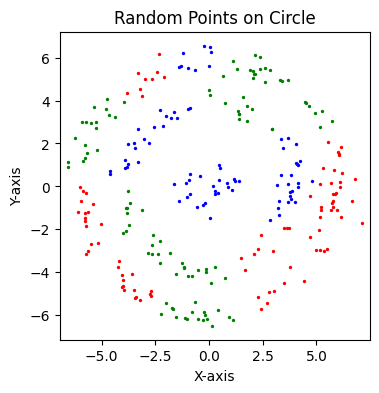

In [18]:
k=rbf_kernel
K=3
max_iter=5
k_matrix=np.zeros((n_samples,n_samples))
for i in range(n_samples):
    for j in range(n_samples):
        k_matrix[i,j]=k(X[i,:],X[j,:])
assignments=np.random.randint(0,K,n_samples)
dassign=np.array([])
for r in range(np.size(radius)):
    dassign=np.append(dassign,r*np.ones((1,factor*radius[r])))
assignments=np.random.choice(dassign,n_samples)
#assignments=dassign
for _ in range(0,max_iter):
    
    distances=np.zeros((n_samples,K))
    for c in range(K):
        m=assignments==c
        distances[:,c]=np.diag(k_matrix)-2*np.mean(k_matrix[:,m],axis=1)+np.mean(k_matrix[np.ix_(m,m)])
    new_assignments=np.argmin(distances,axis=1)
    #if np.array_equal(assignments,new_assignments):
        #break
    assignments=new_assignments
    ksum3=0
    G=0
    for l in range(0,K):
        m=np.where(assignments==l)[0]
        for i in m:
            for j in m:
                ksum3=ksum3+k(X[i,:],X[j,:])
        G=G+(1/np.size(m))*ksum3
    print(G)
colors=['red','green','blue']
plt.figure(figsize=(4, 4))
for l in range(0,K):
    plt.scatter(X[np.where(assignments==l),0],X[np.where(assignments==l),1],s=2,color=colors[l])
plt.axis('equal')  # To maintain aspect ratio 
plt.title('Random Points on Circle') 
plt.xlabel('X-axis') 
plt.ylabel('Y-axis')
plt.show()